# Chapter 1: One-Variable Optimization


> **Source and scope.** This is an original computational companion to Mark M. Meerschaert, *Mathematical Modeling*, 4th ed. (Academic Press, 2013). It follows the chapter structure and reconstructs representative models in Python. It does not reproduce the textbook's prose, figures, or complete exercise sets. Equations, numerical assumptions, and example names are attributed to the book.


This notebook follows Sections 1.1-1.3: the five-step method, sensitivity analysis, and robustness. The main case study is the pig-selling model.


In [1]:
from __future__ import annotations

import platform
import warnings
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sympy as sp
from IPython.display import display

warnings.filterwarnings("ignore", category=RuntimeWarning)
np.set_printoptions(precision=6, suppress=True)
pd.set_option("display.precision", 6)
plt.rcParams["figure.figsize"] = (8, 4.8)

SEED = 20260731
rng = np.random.default_rng(SEED)

versions = pd.Series({
    "Python": platform.python_version(),
    "NumPy": np.__version__,
    "SciPy": scipy.__version__,
    "SymPy": sp.__version__,
    "pandas": pd.__version__,
    "Matplotlib": version("matplotlib"),
}, name="version")
display(versions.to_frame())


,version
Python,3.13.5
NumPy,2.3.5
SciPy,1.17.0
SymPy,1.14.0
pandas,2.2.3
Matplotlib,3.10.8


## 1.1 The five-step method

The chapter's reusable workflow is:

1. Ask a precise question and list variables, units, assumptions, and the objective.
2. Select a modeling approach.
3. Formulate the model in the standard mathematical form.
4. Solve and verify the model.
5. Translate the result back into plain language.

For the pig problem, let \(t\) be days until sale. The price per pound falls linearly, the pig's weight rises linearly, and keeping the pig incurs a daily cost.


In [2]:
t, p0, w0, g, r, c = sp.symbols("t p0 w0 g r c", positive=True, real=True)

price = p0 - r * t
weight = w0 + g * t
profit = sp.expand(price * weight - c * t)
dprofit = sp.diff(profit, t)
d2profit = sp.diff(profit, t, 2)
t_star = sp.simplify(sp.solve(sp.Eq(dprofit, 0), t)[0])

print("Profit function:")
display(sp.Eq(sp.Symbol("P"), profit))
print("Stationary point:")
display(sp.Eq(sp.Symbol("t_star"), t_star))
print("Second derivative:")
display(sp.Eq(sp.Symbol("P''"), d2profit))


Profit function:


Eq(P, -c*t + g*p0*t - g*r*t**2 + p0*w0 - r*t*w0)

Stationary point:


Eq(t_star, (-c + g*p0 - r*w0)/(2*g*r))

Second derivative:


Eq(P'', -2*g*r)

In [3]:
base = {
    p0: sp.Rational(65, 100),
    w0: 200,
    g: 5,
    r: sp.Rational(1, 100),
    c: sp.Rational(45, 100),
}

t_opt = sp.simplify(t_star.subs(base))
p_opt = sp.simplify(profit.subs(base).subs(t, t_opt))

baseline = pd.DataFrame({
    "quantity": ["optimal sale time", "maximum net profit", "second derivative"],
    "value": [float(t_opt), float(p_opt), float(d2profit.subs(base))],
    "unit": ["days", "dollars", "dollars/day^2"],
})
display(baseline)

assert t_opt == 8
assert p_opt == sp.Rational(666, 5)
assert d2profit.subs(base) < 0


,quantity,value,unit
0,optimal sale time,8.0,days
1,maximum net profit,133.2,dollars
2,second derivative,-0.1,dollars/day^2


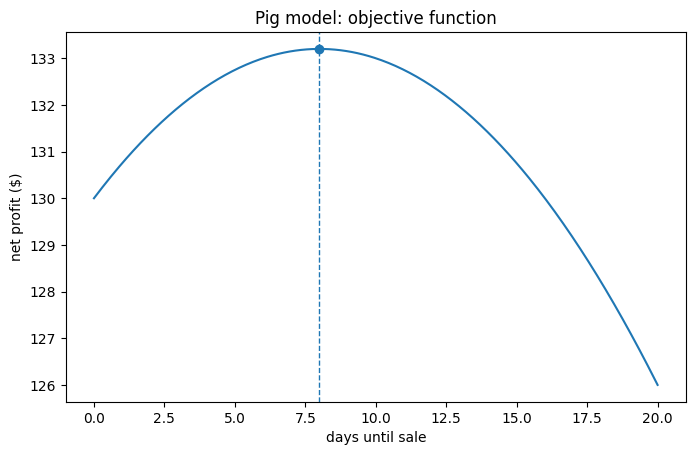

In [4]:
profit_fn = sp.lambdify(t, profit.subs(base), "numpy")
t_grid = np.linspace(0, 20, 401)

plt.plot(t_grid, profit_fn(t_grid))
plt.scatter([float(t_opt)], [float(p_opt)], zorder=3)
plt.axvline(float(t_opt), linestyle="--", linewidth=1)
plt.xlabel("days until sale")
plt.ylabel("net profit ($)")
plt.title("Pig model: objective function")
plt.show()


## 1.2 Sensitivity analysis

For an optimum \(x=x(a)\), the dimensionless sensitivity coefficient is

\[
S(x,a)=\frac{dx}{da}\frac{a}{x}.
\]

It approximately converts a small percentage change in a parameter into the resulting percentage change in the output.


In [5]:
profit_star = sp.simplify(profit.subs(t, t_star))
parameters = [r, g, c, p0, w0]
rows = []
for parameter in parameters:
    sx = sp.simplify(sp.diff(t_star, parameter) * parameter / t_star)
    sy = sp.simplify(sp.diff(profit_star, parameter) * parameter / profit_star)
    rows.append({
        "parameter": str(parameter),
        "S(time, parameter)": float(sx.subs(base)),
        "S(profit, parameter)": float(sy.subs(base)),
    })

sensitivity_table = pd.DataFrame(rows).set_index("parameter")
display(sensitivity_table)

assert np.isclose(sensitivity_table.loc["r", "S(time, parameter)"], -3.5)
assert np.isclose(sensitivity_table.loc["g", "S(time, parameter)"], 3.0625)


,"S(time, parameter)","S(profit, parameter)"
parameter,,
r,-3.5000,-0.144144
g,3.0625,0.171171
c,-0.5625,-0.027027
p0,4.0625,1.171171
w0,-2.5000,0.855856


,price decline ($/lb/day),optimal time (days)
0,0.008,15.000000
1,0.009,11.111111
2,0.010,8.000000
3,0.011,5.454545
4,0.012,3.333333
5,0.014,0.000000
6,0.015,0.000000


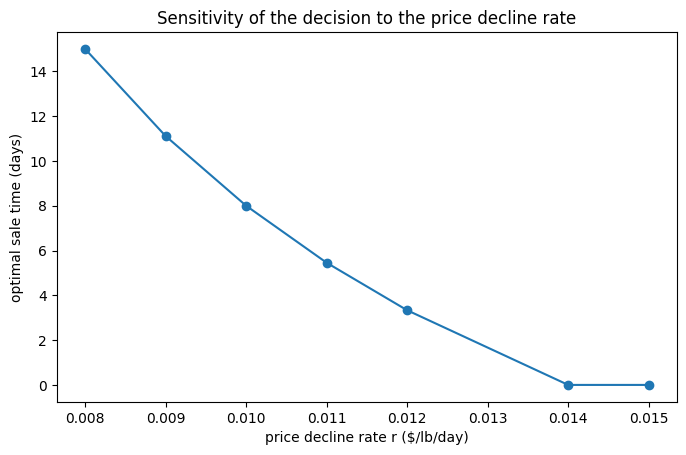

In [6]:
def constrained_optimum_time(rate: float) -> float:
    expression = float(t_star.subs({**base, r: rate}))
    return max(0.0, expression)

rates = np.array([0.008, 0.009, 0.010, 0.011, 0.012, 0.014, 0.015])
opt_times = np.array([constrained_optimum_time(rate) for rate in rates])
rate_sweep = pd.DataFrame({"price decline ($/lb/day)": rates, "optimal time (days)": opt_times})
display(rate_sweep)

plt.plot(rates, opt_times, marker="o")
plt.xlabel("price decline rate r ($/lb/day)")
plt.ylabel("optimal sale time (days)")
plt.title("Sensitivity of the decision to the price decline rate")
plt.show()


## 1.3 Sensitivity and robustness

Sensitivity varies parameter values inside one model. Robustness asks whether the conclusion survives a change in model form. The next calculation replaces the linear price path by the chapter's leveling-off alternative

\[
p(t)=0.65-0.01t+0.00004t^2.
\]

The domain is restricted to 0-65 days. Without a credible domain restriction, polynomial extrapolation eventually wanders into nonsense, as polynomials so often do when humans ask them to predict the universe.


,model,optimal day,maximum profit ($)
0,linear price,8.000000,133.200000
1,leveling price,10.278424,134.002782


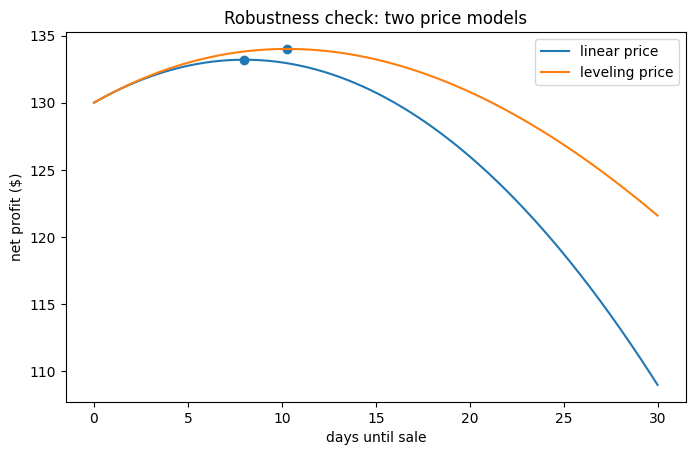

In [7]:
from scipy.optimize import minimize_scalar

linear_profit = sp.lambdify(t, profit.subs(base), "numpy")
level_price = sp.Rational(65, 100) - sp.Rational(1, 100) * t + sp.Rational(4, 100000) * t**2
level_profit_expr = sp.expand(level_price * (200 + 5 * t) - sp.Rational(45, 100) * t)
level_profit = sp.lambdify(t, level_profit_expr, "numpy")

robust_result = minimize_scalar(lambda x: -level_profit(x), bounds=(0, 65), method="bounded")
robust_t = robust_result.x
robust_p = -robust_result.fun

comparison = pd.DataFrame({
    "model": ["linear price", "leveling price"],
    "optimal day": [float(t_opt), robust_t],
    "maximum profit ($)": [float(p_opt), robust_p],
})
display(comparison)

plot_t = np.linspace(0, 30, 500)
plt.plot(plot_t, linear_profit(plot_t), label="linear price")
plt.plot(plot_t, level_profit(plot_t), label="leveling price")
plt.scatter([float(t_opt), robust_t], [float(p_opt), robust_p])
plt.xlabel("days until sale")
plt.ylabel("net profit ($)")
plt.title("Robustness check: two price models")
plt.legend()
plt.show()

assert 10 < robust_t < 11


## Chapter checkpoint

The baseline answer is to sell after eight days, but the decision is much more sensitive to the price-decline estimate than the achieved profit is. This asymmetry is typical near a smooth optimum: the maximizing decision can move noticeably while the objective value changes only slightly.

Suggested extensions: impose integer sale days, estimate parameter uncertainty with bootstrap samples, or optimize a risk-adjusted objective instead of expected profit.
